In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

weekly = pd.read_csv('../dataset/weekly_sales_by_item_features.csv')
weekly['week_start'] = pd.to_datetime(weekly['week_start'], errors='coerce')
weekly = weekly.sort_values(['week_start', 'Item']).copy()

weekly.head()

,YearWeek,Item,week_start,weekly_quantity,weekly_revenue,transaction_count,avg_price_per_unit,month,week_number,lag_qty_1,lag_qty_2,lag_qty_3,avg_qty_last_4_weeks,next_qty,pct_change_next,direction
0,2023-03,Cake,2023-01-16,74.0,222.0,26,3.0,1,3,58.0,78.0,14.0,84.00,78.0,0.054054,similar
49,2023-03,Coffee,2023-01-16,59.0,118.0,19,2.0,1,3,76.0,66.0,14.0,85.25,56.0,-0.050847,similar
98,2023-03,Cookie,2023-01-16,82.0,82.0,25,1.0,1,3,70.0,59.0,4.0,74.25,67.0,-0.182927,decrease
147,2023-03,Juice,2023-01-16,60.0,180.0,19,3.0,1,3,71.0,53.0,6.0,79.25,79.0,0.316667,increase
196,2023-03,Salad,2023-01-16,70.0,350.0,25,5.0,1,3,91.0,83.0,4.0,76.25,67.0,-0.042857,similar


In [10]:
split_date = weekly['week_start'].quantile(0.80)
train_mask = weekly['week_start'] <= split_date
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

In [11]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2:', r2_score(y_test, y_pred))

RMSE: 0.8482768359295838
R2: -0.0006087694480889638


Współczynniki regresji:
week_number             0.231344
month                  -0.231079
avg_qty_last_4_weeks    0.069990
Item                    0.039230
lag_qty_2               0.017642
lag_qty_3               0.008577
lag_qty_1               0.007247
dtype: float64


C:\Users\bkiel\AppData\Local\Temp\ipykernel_48440\1139299178.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefficients.abs().values, y=coefficients.index, palette='viridis')


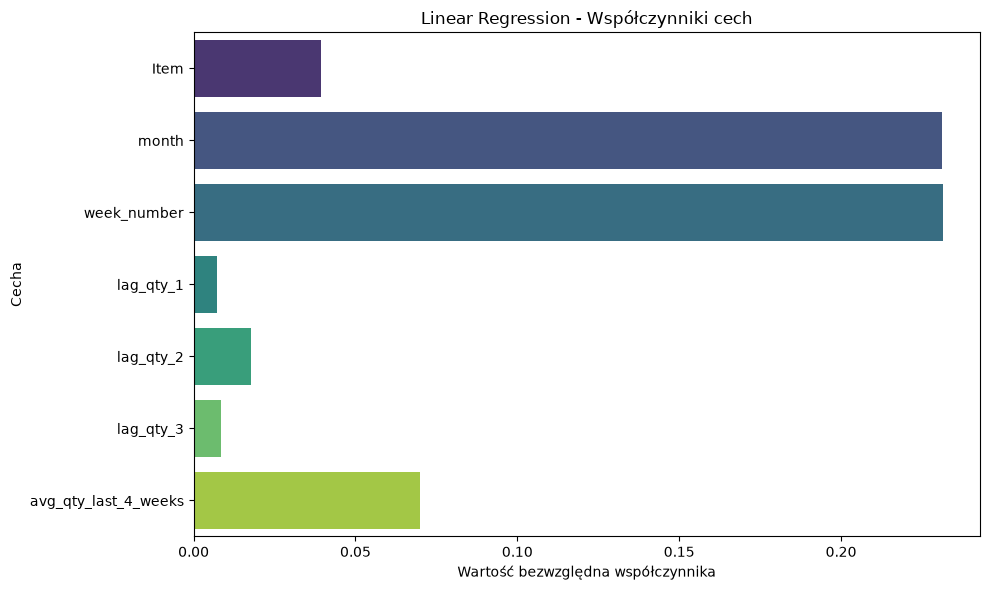

In [12]:

coefficients = pd.Series(lr.coef_, index=features)
print('Współczynniki regresji:')
print(coefficients.sort_values(key=abs, ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(x=coefficients.abs().values, y=coefficients.index, palette='viridis')
plt.title('Linear Regression - Współczynniki cech')
plt.xlabel('Wartość bezwzględna współczynnika')
plt.ylabel('Cecha')
plt.tight_layout()
plt.show()
